## Path configuration

In [2]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [ ]:
import pickle
import numpy as np
import pandas as pd

# utils
from src.config.loader import *
from src.data.datasets import *
from src.data.preprocessing import *
from src.evaluation.metrics import *
from src.visualization.viz import *

# tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

## Data loading

In [4]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]

In [5]:
driams = load_pkl(driams_pkl)

In [6]:
data, label, meta = driams["data"], driams["label"], pd.DataFrame.from_records(list(driams["meta"]))

In [7]:
# Apply normalization: scale each spectrum to [0, 1]
X_min = data.min(axis=1, keepdims=True)
X_max = data.max(axis=1, keepdims=True)
data_norm = (data - X_min) / (X_max - X_min + 1e-8)

### DRIAMS-A

In [8]:
mask_A = meta["hospital"] == "DRIAMS_A"

data_A = data_norm[mask_A.values]
label_A = label[mask_A.values]
meta_A = meta.loc[mask_A].reset_index(drop=True)

In [9]:
data_by_year = {}
labels_by_year = {}
meta_by_year = {}

for year in ["2015", "2016", "2017", "2018"]:
    mask_y = meta_A["year"] == year
    data_by_year[year] = data_A[mask_y.values]
    labels_by_year[year] = label_A[mask_y.values]
    meta_by_year[year] = meta_A.loc[mask_y].reset_index(drop=True)

    print(f"DRIAMS-A {year}: {data_by_year[year].shape[0]} samples")

DRIAMS-A 2015: 628 samples
DRIAMS-A 2016: 7952 samples
DRIAMS-A 2017: 11135 samples
DRIAMS-A 2018: 8095 samples


## RF, DRIAMS-A 2015 against 2016-17-18

In [10]:
data2015 = data_by_year["2015"]
label2015 = labels_by_year["2015"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    data2015,
    label2015,
    test_size=0.2,
    stratify=label2015,
    shuffle=True,
    random_state=42
)

#### Train

In [12]:
load_previous_rf = False
if not load_previous_rf:
    rf_final = RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    )
    #with open("models/baselines/trained_models/rf_baseline_normalized.pkl", "wb") as f:
    #    pickle.dump(rf_final, f)
    rf_final.fit(X_train, y_train)
else:
    print("Loading previous RF...")
    with open("models/baselines/trained_models/rf_baseline_normalized.pkl", "rb") as f:
        rf_final = pickle.load(f)

#### Test

In [13]:
metrics2015 = metrics_report(X_test, y_test, rf_final, "DRIAMS-A (2015)")
metrics2016 = metrics_report(data_by_year["2016"], labels_by_year["2016"], rf_final, "DRIAMS-A (2016)")
metrics2017 = metrics_report(data_by_year["2017"], labels_by_year["2017"], rf_final, "DRIAMS-A (2017)")
metrics2018 = metrics_report(data_by_year["2018"], labels_by_year["2018"], rf_final, "DRIAMS-A (2018)")


===== Metrics =====
Domain: DRIAMS-A (2015)
Balanced Accuracy: 1.0000
F1 Macro: 1.0000
Recall Macro: 1.0000
Specificity Macro: 1.0000



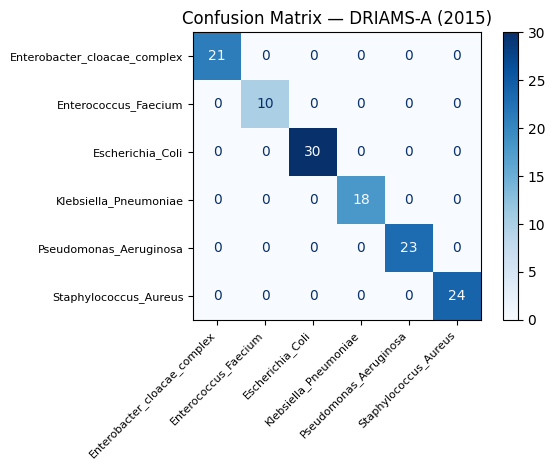

In [14]:
print_metrics(metrics2015)


===== Metrics =====
Domain: DRIAMS-A (2016)
Balanced Accuracy: 0.9959
F1 Macro: 0.9956
Recall Macro: 0.9959
Specificity Macro: 0.9993



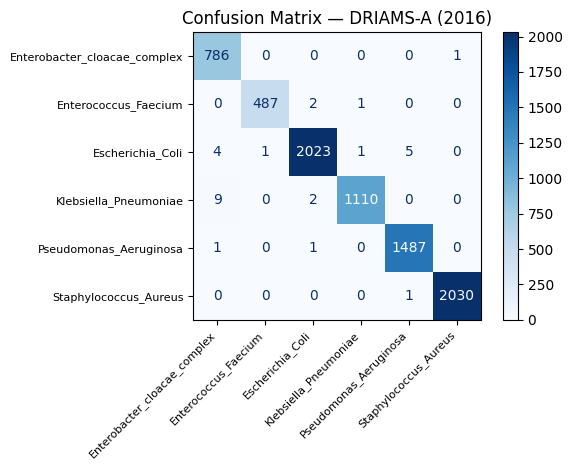

In [15]:
print_metrics(metrics2016)


===== Metrics =====
Domain: DRIAMS-A (2017)
Balanced Accuracy: 0.9955
F1 Macro: 0.9952
Recall Macro: 0.9955
Specificity Macro: 0.9992



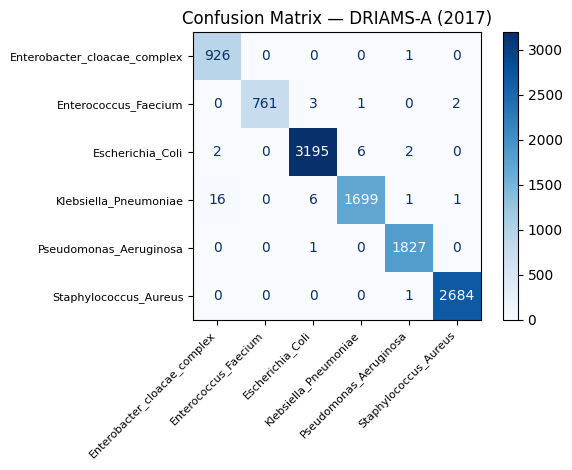

In [16]:
print_metrics(metrics2017)


===== Metrics =====
Domain: DRIAMS-A (2018)
Balanced Accuracy: 0.9924
F1 Macro: 0.9916
Recall Macro: 0.9924
Specificity Macro: 0.9988



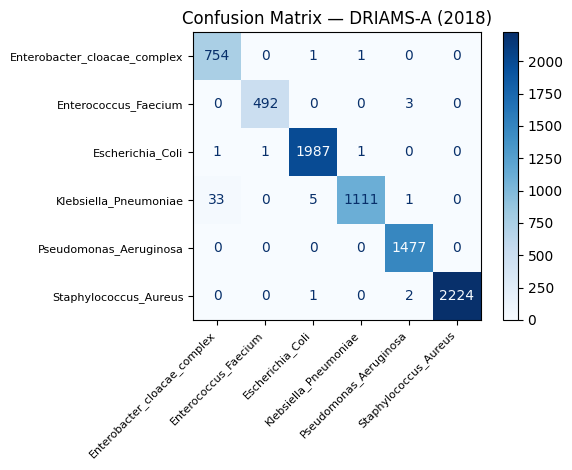

In [17]:
print_metrics(metrics2018)

#### t-SNEs

In [18]:
load_global_pca = False

if not load_global_pca:
    pca_global = PCA(n_components=50, random_state=42)
    X_all_pca = pca_global.fit_transform(
        np.vstack([
            data_by_year["2015"],
            data_by_year["2016"],
            data_by_year["2017"],
            data_by_year["2018"]
        ])
    )
else:
    with open("models/baselines/trained_models/pca_global.pkl", "rb") as f:
        pca_global = pickle.load(f)
        X_all_pca = pca_global.transform(
            np.vstack([
                data_by_year["2015"],
                data_by_year["2016"],
                data_by_year["2017"],
                data_by_year["2018"]
            ])
        )

In [19]:
tsne_df = compute_tsne_df(
    X_all_pca,
    np.concatenate([
        labels_by_year["2015"],
        labels_by_year["2016"],
        labels_by_year["2017"],
        labels_by_year["2018"]
    ]),
    pd.concat([
        meta_by_year["2015"],
        meta_by_year["2016"],
        meta_by_year["2017"],
        meta_by_year["2018"]
    ], ignore_index=True)
)

##### Global


===== t-SNE: Global (colored by species) =====


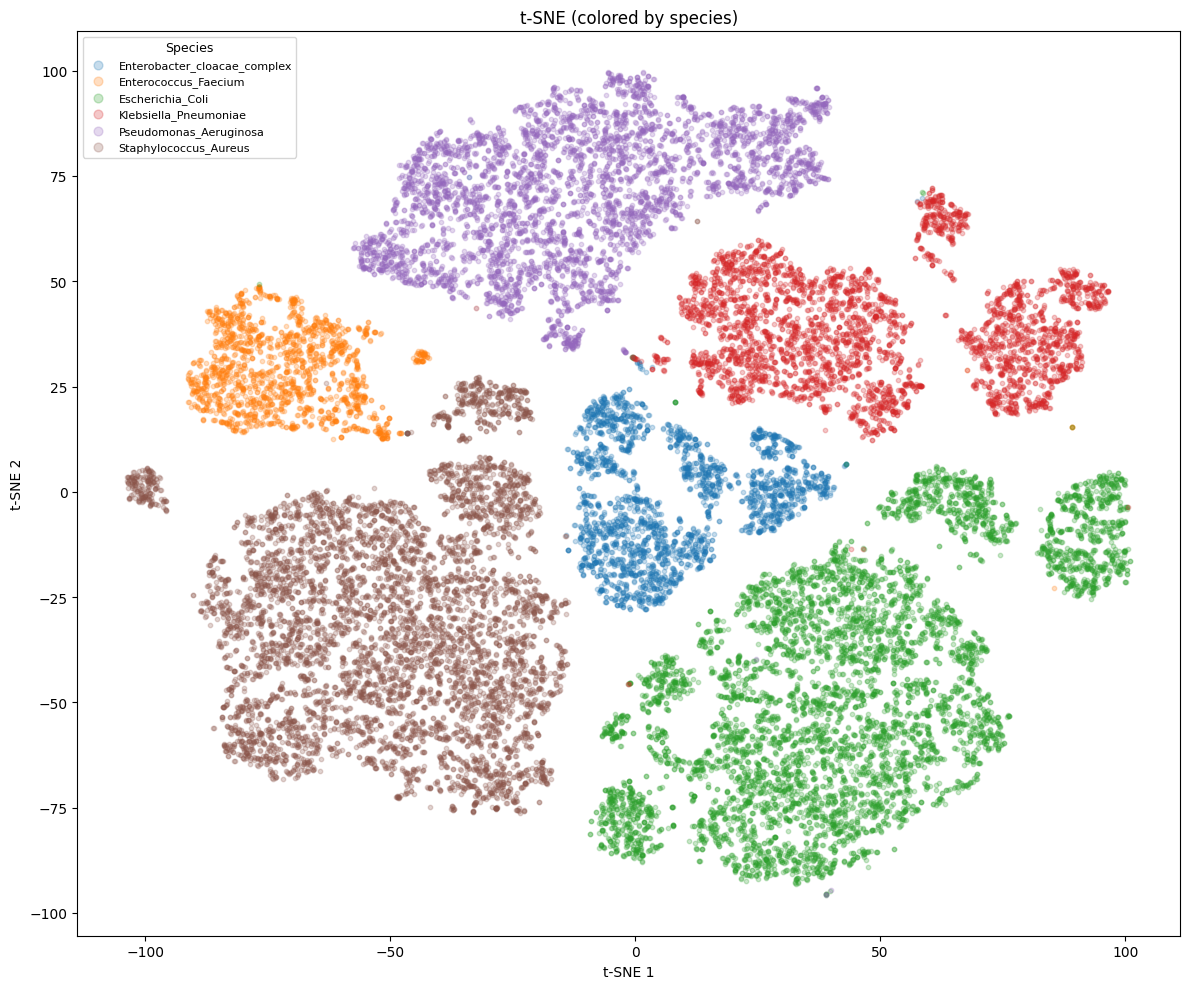


===== t-SNE: Per-species (colored by hospital) =====


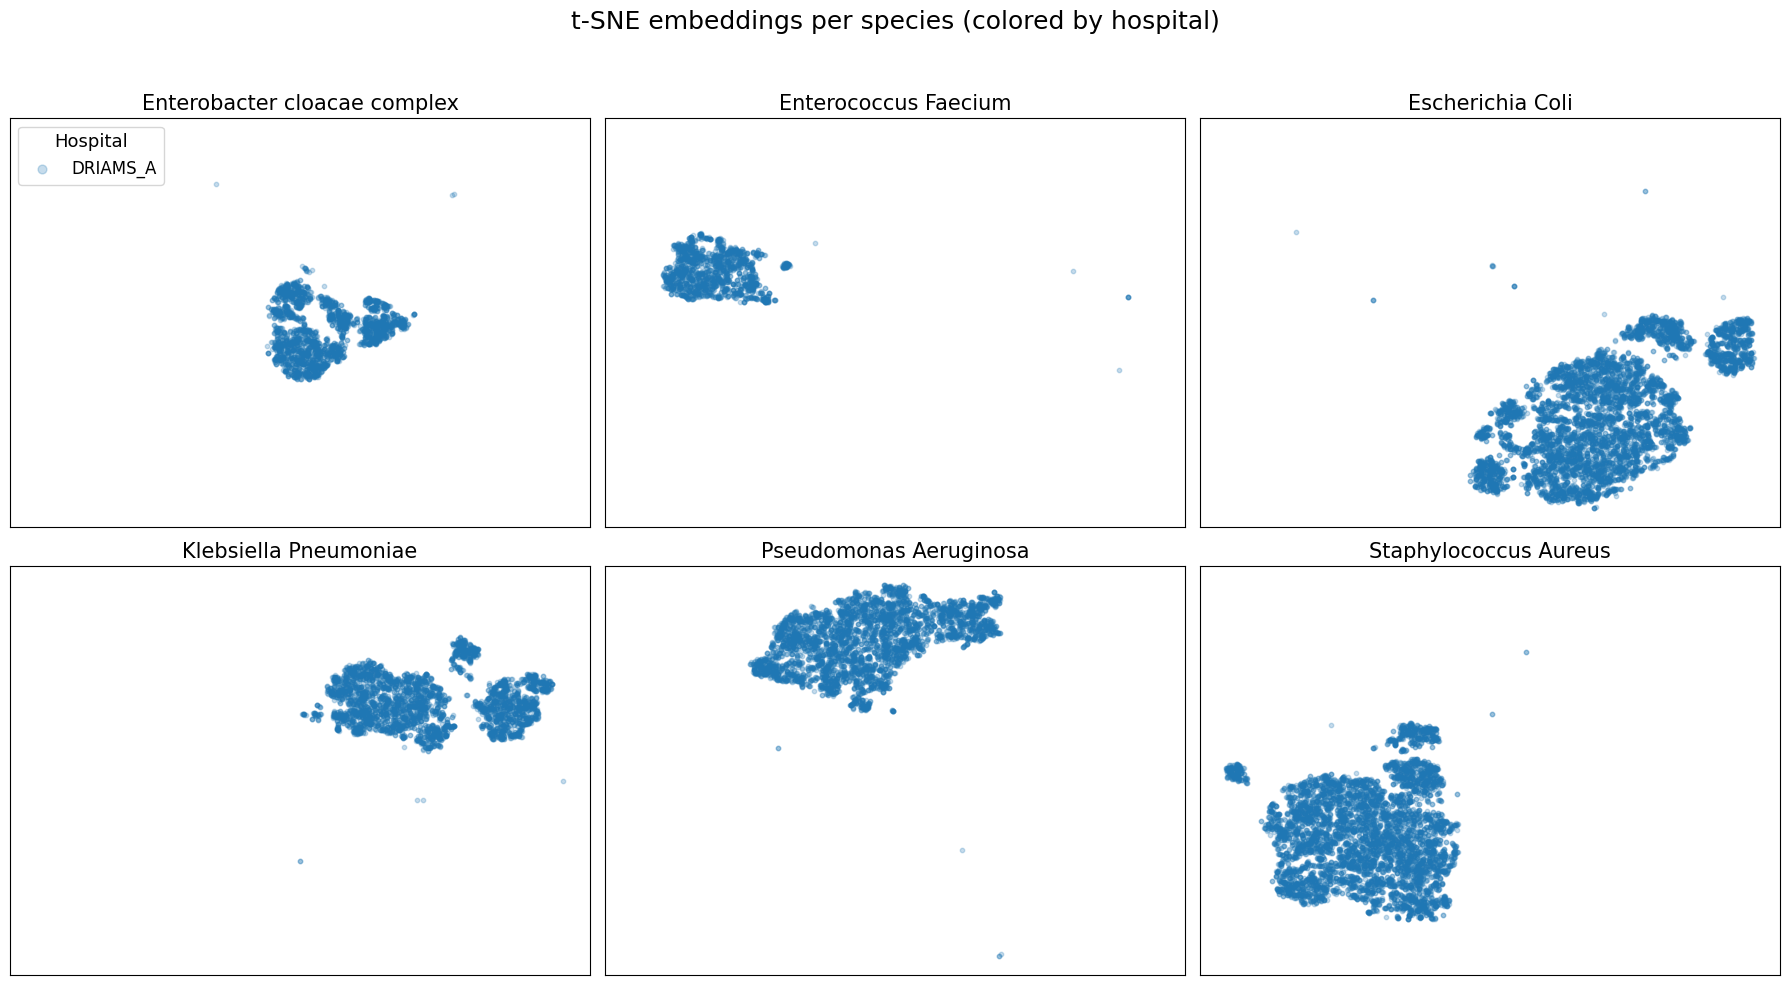


===== t-SNE: Per-species (overlay per year) =====


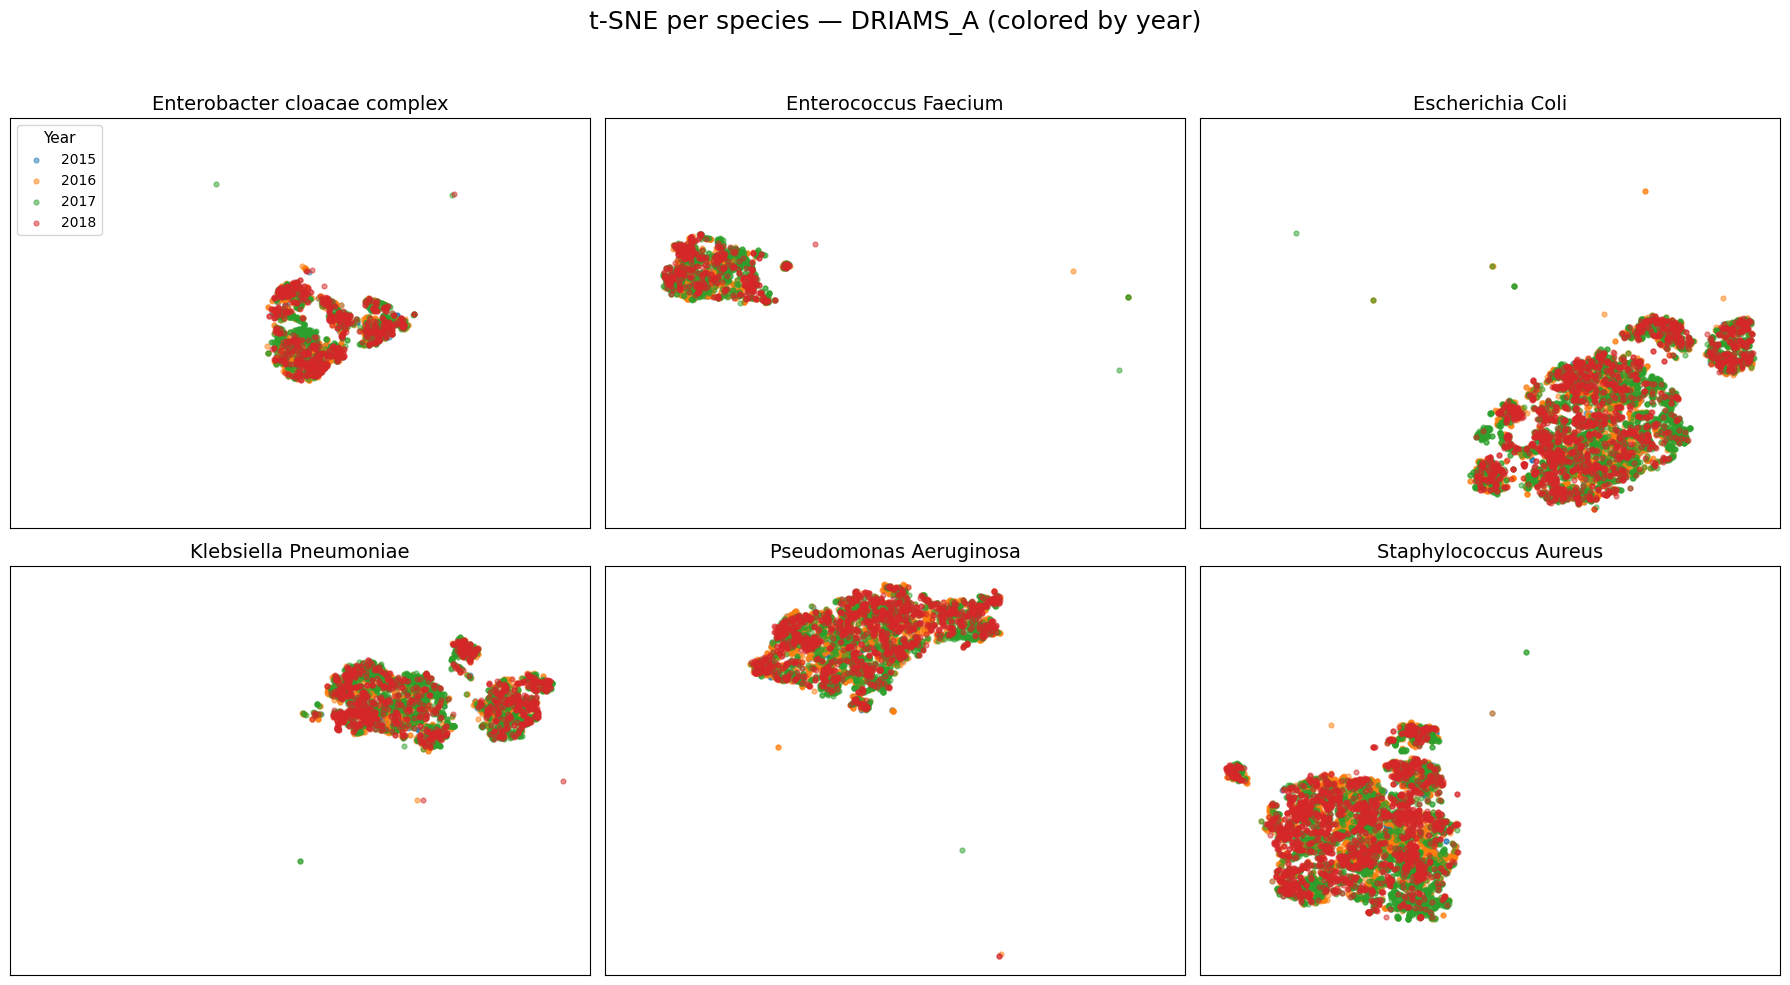

In [23]:
print("\n===== t-SNE: Global (colored by species) =====")
plot_tsne_global(tsne_df, per_species=False)

print("\n===== t-SNE: Per-species (colored by hospital) =====")
plot_tsne_global(tsne_df, per_species=True)

print("\n===== t-SNE: Per-species (overlay per year) =====")
plot_tsne_global(tsne_df, per_species=True, overlay_per_year=True)

##### Per species


===== t-SNE (per species): overlay per year =====


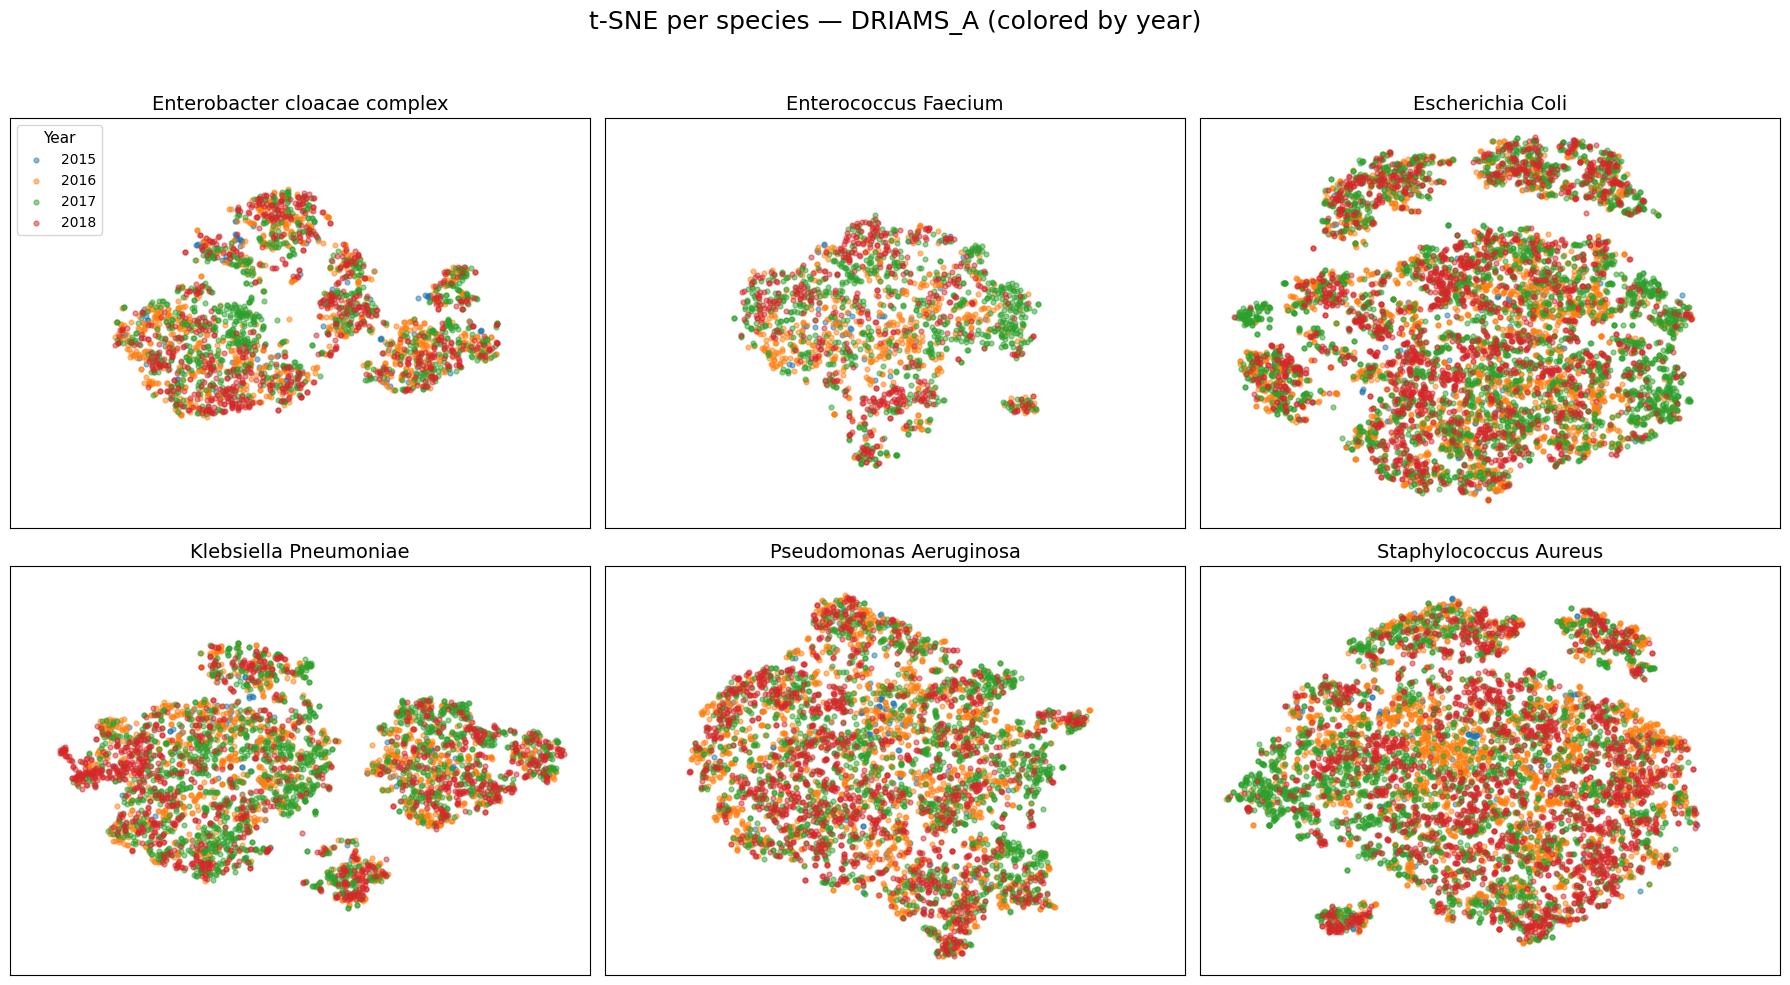

In [24]:
df_all, tsne_results = compute_tsne_per_species(
    X_all_pca,
    np.concatenate([
        labels_by_year["2015"],
        labels_by_year["2016"],
        labels_by_year["2017"],
        labels_by_year["2018"]
    ]),
    pd.concat([
        meta_by_year["2015"],
        meta_by_year["2016"],
        meta_by_year["2017"],
        meta_by_year["2018"]
    ], ignore_index=True),
    prefix="f"
)

print("\n===== t-SNE (per species): overlay per year =====")
plot_tsne_species(df_all, tsne_results, overlay_per_year_per_species=True)